In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("student_data.csv")
df.head()

,StudyHours,Attendance,ParentalEducation,InternetAccess,PreviousMarks,FinalScore
0,2,51,2,0,54,30
1,2,93,0,1,42,27
2,2,63,1,0,75,39
3,9,76,1,1,77,58
4,1,98,1,1,61,38


In [3]:
df.isnull().sum()

StudyHours           0
Attendance           0
ParentalEducation    0
InternetAccess       0
PreviousMarks        0
FinalScore           0
dtype: int64

In [4]:
df = df.dropna()

In [5]:
df.dtypes

StudyHours           int64
Attendance           int64
ParentalEducation    int64
InternetAccess       int64
PreviousMarks        int64
FinalScore           int64
dtype: object

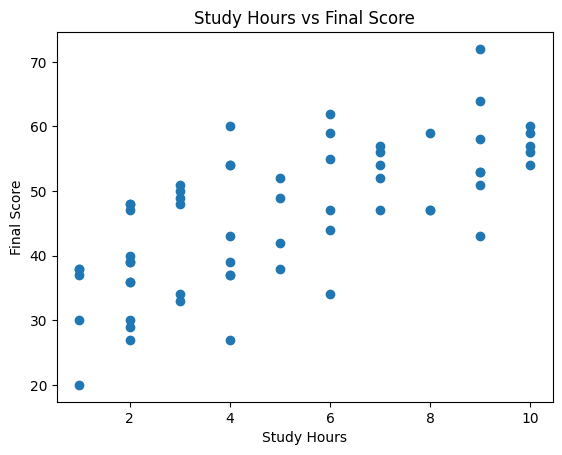

In [24]:
plt.scatter(df["StudyHours"], df["FinalScore"])
plt.xlabel("Study Hours")
plt.ylabel("Final Score")
plt.title("Study Hours vs Final Score")

plt.savefig("study_hours_vs_score.png",dpi=300)  
plt.show()

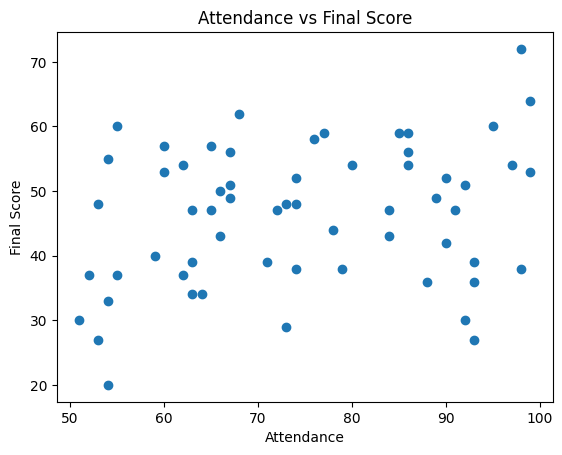

In [25]:
plt.scatter(df["Attendance"], df["FinalScore"])
plt.xlabel("Attendance")
plt.ylabel("Final Score")
plt.title("Attendance vs Final Score")

plt.savefig("attendance_vs_score.png",dpi=300)
plt.show()

In [9]:
X = df[["StudyHours", "Attendance", "ParentalEducation", "InternetAccess", "PreviousMarks"]]

y = df["FinalScore"]

In [10]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42
)

In [11]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [13]:
from sklearn.metrics import r2_score
y_pred = model.predict(X_test)
accuracy = r2_score(y_test, y_pred)
"Model Accuracy:", accuracy

('Model Accuracy:', 0.9295359495129337)

In [14]:
prediction = model.predict([[6, 85, 2, 1, 72]])
"Predicted Final Score:", prediction[0]

C:\Users\KIIT\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


('Predicted Final Score:', np.float64(52.529189050599115))

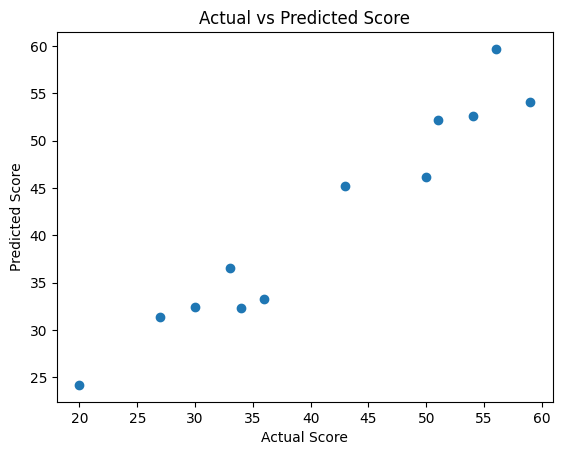

In [26]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.title("Actual vs Predicted Score")

plt.savefig("prediction_graph.png",dpi=300,bbox_inches="tight")
plt.show()